Processing 50 songs for visualization...
Matrix shape: (50, 24)

✓ Map saved to data/hybrid_cluster_map.png


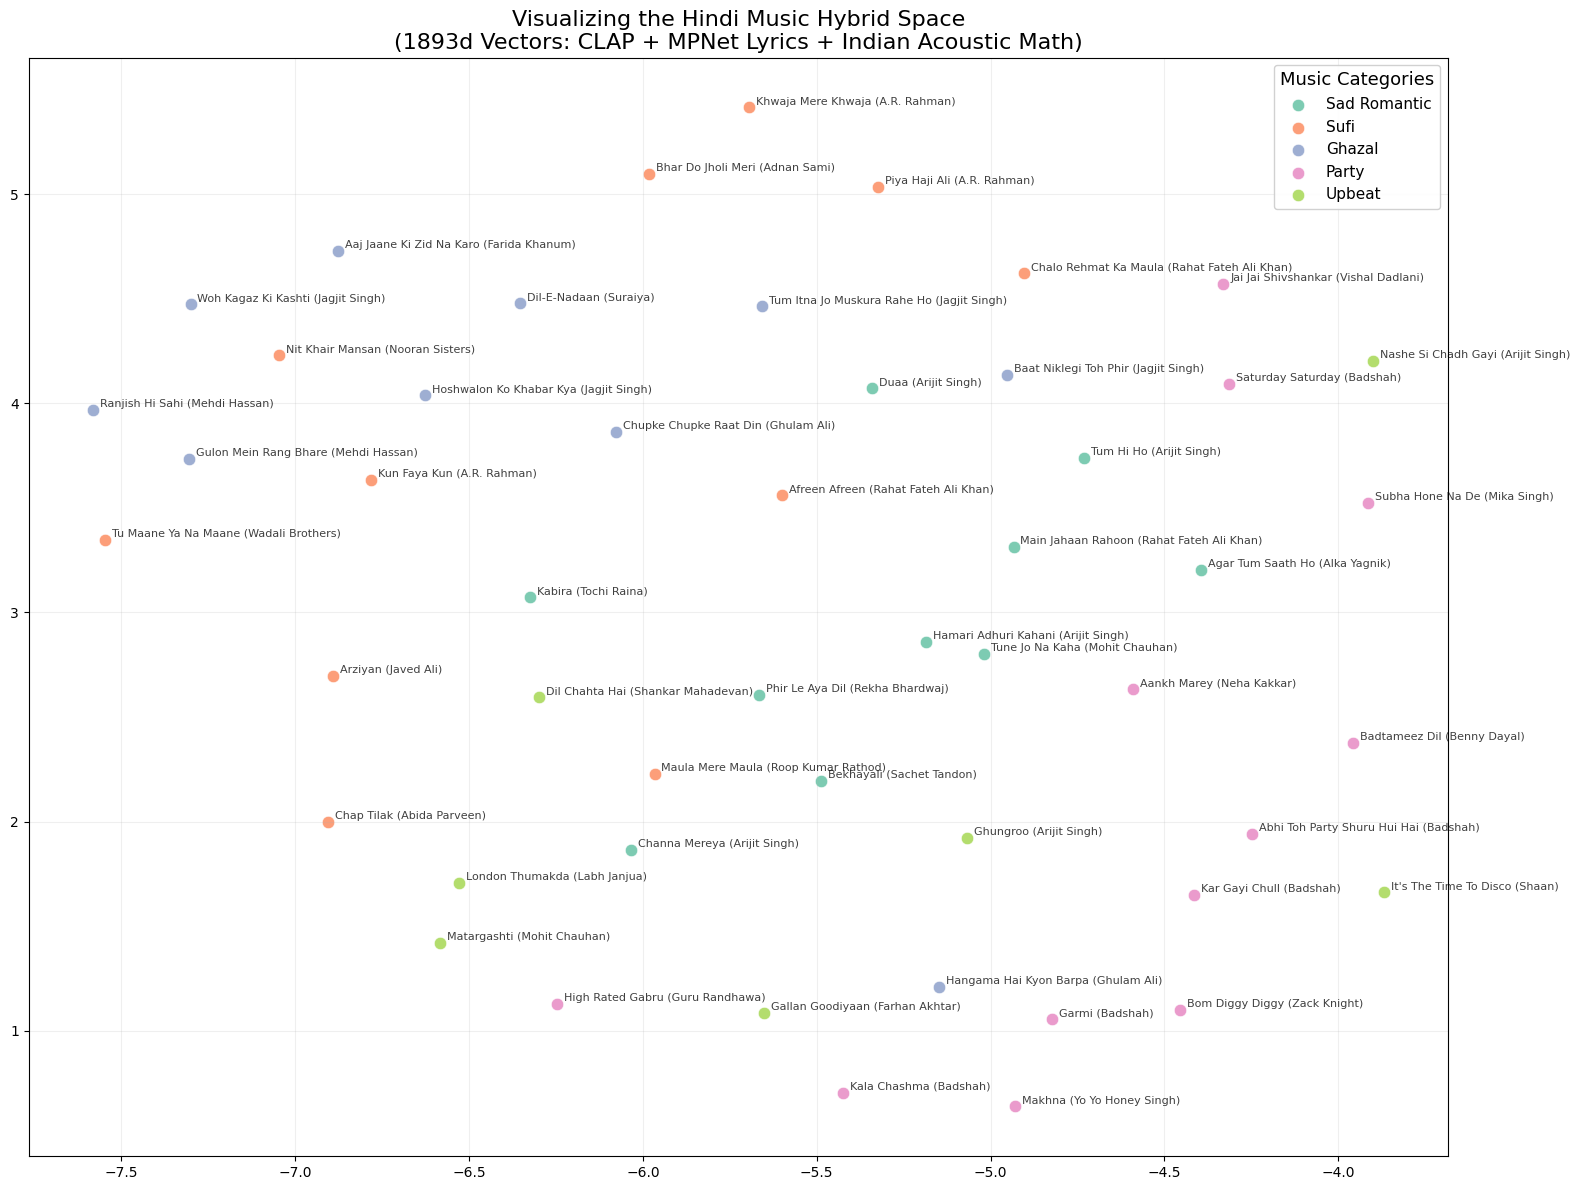

In [16]:
import os
# 1. Force OpenMP to accept multiple runtimes (fixes the macOS libomp crash on Mac)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
import numpy as np
import umap
import matplotlib.pyplot as plt

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.insert(0, ".")
from utils.db import get_all_songs
from pipeline.embedder import load_embedding

# --- Setup ---
songs = get_all_songs()
embeddings = []
labels = []
artists = []
categories = [] # NEW: Track the category for color-coding

print(f"Processing {len(songs)} songs for visualization...")

for song in songs:
    title    = song[1]
    artist   = song[2]
    category = song[4]  # Index 4 holds the 'ghazal', 'party', etc. labels
    emb_path = song[7]  
    
    # Load the unified embedding vector
    if isinstance(emb_path, str) and os.path.exists(emb_path):
        combined_vec = load_embedding(emb_path)
        # Defensively flatten to ensure all vectors are perfectly 1D (e.g., 1893,)
        embeddings.append(combined_vec.flatten())
        labels.append(title)   
        artists.append(artist)
        categories.append(category)

if not embeddings:
    print("No valid embeddings found. Check your data directories.")
else:
    matrix = np.vstack(embeddings)
    print(f"Matrix shape: {matrix.shape}")

    # Reduce to 2D using Cosine Metric
    reducer = umap.UMAP(
        n_neighbors=min(15, len(embeddings) - 1),      
        min_dist=0.15,        
        metric="cosine",     
        n_epochs=1000,       
        random_state=42
    )
    embedding_2d = reducer.fit_transform(matrix)

    # Plot Setup
    plt.figure(figsize=(16, 12))
    
    # NEW: Dynamic Color Mapping
    unique_categories = list(set(categories))
    # Using a vibrant qualitative colormap
    cmap = plt.get_cmap("Set2") 
    
    # Scatter plot each category group individually so we get a nice legend
    for i, cat in enumerate(unique_categories):
        # Find all songs that belong to this specific category
        idx = [j for j, c in enumerate(categories) if c == cat]
        
        plt.scatter(
            embedding_2d[idx, 0], 
            embedding_2d[idx, 1], 
            alpha=0.85, 
            s=80, 
            label=cat.replace('_', ' ').title(), # Clean up labels (e.g. 'sad_romantic' -> 'Sad Romantic')
            color=cmap(i % cmap.N),
            edgecolors='white',
            linewidth=0.5
        )

    # Add the text annotations for the song titles
    for i, label in enumerate(labels):
        display_text = f"{label} ({artists[i]})"
        plt.annotate(
            display_text, 
            (embedding_2d[i, 0], embedding_2d[i, 1]), 
            fontsize=8, 
            alpha=0.75, 
            xytext=(5, 2), 
            textcoords='offset points'
        )

    plt.title("Visualizing the Hindi Music Hybrid Space\n(1893d Vectors: CLAP + MPNet Lyrics + Indian Acoustic Math)", fontsize=16)
    
    # Add the legend to the plot
    plt.legend(title="Music Categories", fontsize=11, title_fontsize=13, loc="best", framealpha=0.9)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    
    os.makedirs("data", exist_ok=True)
    plt.savefig("data/hybrid_cluster_map.png", dpi=200)
    print("\n✓ Map saved to data/hybrid_cluster_map.png")
    plt.show()